In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

2025-04-29 04:43:13.339277: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745901793.360670     134 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745901793.367209     134 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
! pip install mplfinance
! pip install pandas_ta

In [3]:
data = pd.read_csv('/kaggle/input/eurusd60/EURUSD-60-DS-redate.csv')
data.head()

,Date,Open,High,Low,Close,Volume
0,15.08.2017 00:00:00.000,1.17786,1.17812,1.17750,1.17759,6070.48
1,15.08.2017 01:00:00.000,1.17759,1.17802,1.17752,1.17783,3163.99
2,15.08.2017 02:00:00.000,1.17783,1.17802,1.17682,1.17755,4086.81
3,15.08.2017 03:00:00.000,1.17757,1.17895,1.17751,1.17811,6937.33
4,15.08.2017 04:00:00.000,1.17812,1.17928,1.17812,1.17855,7265.10


In [ ]:
# import pandas as pd
# import pandas_ta as ta
# import numpy as np

# data['RSI_14'] = ta.rsi(data['Close'], length=14)

# # تعریف تابع برای محاسبه میانگین وزن‌دار
# def weighted_moving_average(series, window):
#     weights = np.arange(1, window + 1)  # وزن‌های خطی: [1, 2, ..., window]
#     return series.rolling(window).apply(lambda x: np.sum(x * weights) / weights.sum(), raw=True)

# # تنظیم تعداد روزهای گذشته (پنجره)
# n = 16  # می‌توانید این مقدار را تغییر دهید

# # محاسبه میانگین وزن‌دار برای OHLC
# data['WMA_Open'] = weighted_moving_average(data['Open'], n)
# data['WMA_High'] = weighted_moving_average(data['High'], n)
# data['WMA_Low'] = weighted_moving_average(data['Low'], n)
# data['WMA_Close'] = weighted_moving_average(data['Close'], n)

# # تبدیل ستون Date به فرمت datetime
# data['Date'] = pd.to_datetime(data['Date'], format='%d.%m.%Y %H:%M:%S.%f')

# # استخراج Hour_of_Day و Day_of_Week
# data['Hour_of_Day'] = data['Date'].dt.hour
# data['Day_of_Week'] = data['Date'].dt.dayofweek

# # نگه‌داشتن فقط ستون‌های مورد نیاز
# data = data[['Date', 'Open', 'High', 'Low', 'Close', 
#              'RSI_14', 
#              'WMA_Open', 'WMA_High', 'WMA_Low', 'WMA_Close', 
#              'Hour_of_Day', 'Day_of_Week']]

# # حذف ردیف‌های دارای NaN
# data = data.dropna()

# data.head()

In [ ]:
# input_features = [ 'Open', 'High', 'Low', 'Close', 
#              'RSI_14', 
#              'WMA_Open', 'WMA_High', 'WMA_Low', 'WMA_Close', 
#              'Hour_of_Day']
# scalers_inputs = {col: MinMaxScaler() for col in input_features}
# scaled_inputs = np.array([scalers_inputs[col].fit_transform(data[col].values.reshape(-1, 1)) for col in input_features])
# scaled_inputs = np.transpose(scaled_inputs, (1, 0, 2))

# # 3. انتخاب تارگت (OHLC)
# output_features = ['Open', 'High', 'Low', 'Close']
# scalers_outputs = {col: MinMaxScaler() for col in output_features}
# scaled_outputs = np.array([scalers_outputs[col].fit_transform(data[col].values.reshape(-1, 1)) for col in output_features])
# scaled_outputs = np.transpose(scaled_outputs, (1, 0, 2))
# if len(scaled_inputs.shape) > 2:
#     scaled_inputs = scaled_inputs.reshape(scaled_inputs.shape[0], scaled_inputs.shape[1])
# if len(scaled_outputs.shape) > 2:
#     scaled_outputs = scaled_outputs.reshape(scaled_outputs.shape[0], scaled_outputs.shape[1])

In [4]:
# epsilon = 1e-10
# data = np.log(data[['Open', 'High', 'Low', 'Close']] + epsilon)

data['Date'] = pd.to_datetime(data['Date'])  # تبدیل ستون تاریخ به فرمت datetime
data = data[data['Date'] >= '2023-01-01']

/tmp/ipykernel_134/2114371809.py:4: UserWarning: Parsing dates in %d.%m.%Y %H:%M:%S.%f format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['Date'] = pd.to_datetime(data['Date'])  # تبدیل ستون تاریخ به فرمت datetime


In [5]:
# input_features = ['Open', 'High', 'Low', 'Close']
# scalers_inputs = {col: MinMaxScaler() for col in input_features}
# scaled_inputs = np.array([scalers_inputs[col].fit_transform(data[col].values.reshape(-1, 1)) for col in input_features])
# scaled_inputs = np.transpose(scaled_inputs, (1, 0, 2))

# # 3. انتخاب تارگت (OHLC)
# output_features = ['Open', 'High', 'Low', 'Close']
# scalers_outputs = {col: MinMaxScaler() for col in output_features}
# scaled_outputs = np.array([scalers_outputs[col].fit_transform(data[col].values.reshape(-1, 1)) for col in output_features])
# scaled_outputs = np.transpose(scaled_outputs, (1, 0, 2))

input_features = ['Open', 'High', 'Low', 'Close']
data_values = data[input_features].values  # آرایه numpy با شکل (n_samples, 4)

# نرمال‌سازی با مقیاس مشترک
flat_data = data_values.reshape(-1, 1)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(flat_data).reshape(data_values.shape)
scaled_inputs = scaled_data.reshape(-1, len(input_features), 1)
scaled_outputs = scaled_inputs  # اگر خروجی هم OHLC است

In [6]:
# def create_sequences(inputs, outputs, seq_length):
#     X, y = [], []
#     for i in range(len(inputs) - seq_length):
#         X.append(inputs[i:i + seq_length])
#         y.append(outputs[i + seq_length])  # 4 مقدار OHLC تایم‌فریم بعدی
#     return np.array(X), np.array(y)

# seq_length = 10
# X, y = create_sequences(scaled_inputs, scaled_outputs, seq_length)


def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 48
X, y = create_sequences(scaled_inputs, seq_length)

In [7]:
train_size = int(len(X) * 0.8)
val_size = int(len(X) * 0.1)
X_train, X_val, X_test = X[:train_size], X[train_size:train_size + val_size], X[train_size + val_size:]
y_train, y_val, y_test = y[:train_size], y[train_size:train_size + val_size], y[train_size + val_size:]

print("تعداد نمونه‌های Train:", len(X_train))
print("تعداد نمونه‌های Validation:", len(X_val))
print("تعداد نمونه‌های Test:", len(X_test))

تعداد نمونه‌های Train: 9818
تعداد نمونه‌های Validation: 1227
تعداد نمونه‌های Test: 1228


In [ ]:
data['Date'] = pd.to_datetime(data['Date'], format='%d.%m.%Y %H:%M:%S.%f')
data['Day'] = data['Date'].dt.date
daily_data = data.groupby('Day').first().reset_index()  # اولین نمونه هر روز

# 4. رسم Line Plot برای Close
plt.figure(figsize=(12, 6))
plt.plot(daily_data['Date'], daily_data['Close'], label='Close', color='blue')

# 5. تنظیمات نمودار
plt.title('EUR/USD trend')
plt.xlabel('date')
plt.ylabel('Close')
plt.legend()
plt.grid(True)

# 6. نمایش
plt.show()

In [52]:
del model

In [53]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Lambda, Bidirectional
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# # بهینه‌ساز و تابع loss
# def lr_schedule(epoch):
#     # حد مشخص برای تغییر رفتار کاهش نرخ یادگیری
#     threshold_epoch = 40
#     # فاکتورها و بازه‌های کاهش
#     initial_lr = 1e-5
#     target_lr = 0.001  # هدف برای ایپاک‌های اولیه
#     peak_lr = 0.002    # اوج نرخ یادگیری در ایپاک 15-16
    
#     if epoch < 15:
#         # افزایش خطی از 1e-5 به 0.001 در 15 ایپاک اول
#         return initial_lr + (target_lr - initial_lr) * (float(epoch + 1) / 15)
#     elif 15 <= epoch < 17:
#         # نرخ یادگیری ثابت 0.002 برای ایپاک 15 و 16
#         return peak_lr
#     elif 17 <= epoch < threshold_epoch:
#         # کاهش با فاکتور 0.25 هر 5 ایپاک تا رسیدن به ایپاک 50
#         return peak_lr * (0.25 ** ((epoch - 17) // 5))
#     else:
#         # محاسبه نرخ یادگیری تا ایپاک 50
#         lr_at_threshold = peak_lr * (0.25 ** ((threshold_epoch - 1 - 17) // 5))
#         # کاهش سریع‌تر با فاکتور 0.1 هر 3 ایپاک بعد از ایپاک 50
#         return lr_at_threshold * (0.1 ** ((epoch - threshold_epoch) // 3))
# # def lr_schedule(epoch):
#     if epoch < 15:
#         return 1e-5 + (0.001 - 1e-5) * (float(epoch + 1) / 15)
#     elif 15 <= epoch < 17:
#         return 0.002
#     else:
#         return 0.002 * (0.25 ** ((epoch - 17) // 5))
        

import tensorflow as tf

def custom_ohlc_loss(y_true, y_pred, close_weight=2.0, alpha_penalty=0.4, beta_penalty=0.4, directional_weight=3.0, high_low_weight=1.5):

    # Extract OHLC components
    open_true, high_true, low_true, close_true = tf.split(y_true, 4, axis=-1)
    open_pred, high_pred, low_pred, close_pred = tf.split(y_pred, 4, axis=-1)
    
    # Calculate absolute differences
    open_loss = tf.reduce_mean(tf.abs(open_true - open_pred))
    high_loss = tf.reduce_mean(tf.abs(high_true - high_pred))
    low_loss = tf.reduce_mean(tf.abs(low_true - low_pred))
    close_loss = tf.reduce_mean(tf.abs(close_true - close_pred)) * close_weight
    
    # Sum of absolute differences
    abs_loss = open_loss + high_loss + low_loss + close_loss
    
    # Alpha penalty: Low should be <= Open, High, Close
    alpha_condition = tf.reduce_any([
        low_pred > open_pred,
        low_pred > high_pred,
        low_pred > close_pred
    ], axis=0)
    alpha = tf.where(alpha_condition, alpha_penalty, 0.0)
    alpha = tf.reduce_mean(tf.cast(alpha, tf.float32))
    
    # Beta penalty: High should be >= Open, Low, Close
    beta_condition = tf.reduce_any([
        high_pred < open_pred,
        high_pred < low_pred,
        high_pred < close_pred
    ], axis=0)
    beta = tf.where(beta_condition, beta_penalty, 0.0)
    beta = tf.reduce_mean(tf.cast(beta, tf.float32))
    
    # High-Low difference (weighted more to capture volatility)
    high_low_true = tf.abs(high_true - low_true)
    high_low_pred = tf.abs(high_pred - low_pred)
    high_low_diff = tf.reduce_mean(tf.abs(high_low_true - high_low_pred)) * high_low_weight
    
    # Directional loss: Penalize incorrect direction of Close changes
    # close_true_diff = close_true[1:] - close_true[:-1]  # تغییرات Close واقعی
    # close_pred_diff = close_pred[1:] - close_pred[:-1]  # تغییرات Close پیش‌بینی‌شده
    # direction_mismatch = tf.reduce_mean(tf.cast(tf.sign(close_true_diff) != tf.sign(close_pred_diff), tf.float32))
    # directional_loss = direction_mismatch * directional_weight
    true_direction = tf.sign(close_true - open_true)
    pred_direction = tf.sign(close_pred - open_pred)
    # Penalize mismatch in direction.
    # tf.cast(tf.not_equal(true_direction, pred_direction), tf.float32) gives 1.0 for mismatch, 0.0 for match
    direction_mismatch = tf.cast(tf.not_equal(true_direction, pred_direction), tf.float32)
    directional_loss = tf.reduce_mean(direction_mismatch) * directional_weight
    
    # Total loss
    total_loss = abs_loss + alpha + beta + high_low_diff + directional_loss
    
    return total_loss

# def custom_ohlc_loss(y_true, y_pred, close_weight=2.0, alpha_penalty=0.4, beta_penalty=0.4, directional_weight=1.2, high_low_weight=1.5):

#     # Extract OHLC components ( shape will be (batch_size, 1) after split)
#     open_true, high_true, low_true, close_true = tf.split(y_true, 4, axis=-1)
#     open_pred, high_pred, low_pred, close_pred = tf.split(y_pred, 4, axis=-1)

#     # Calculate absolute differences
#     open_loss = tf.reduce_mean(tf.abs(open_true - open_pred))
#     high_loss = tf.reduce_mean(tf.abs(high_true - high_pred))
#     low_loss = tf.reduce_mean(tf.abs(low_true - low_pred))
#     close_loss = tf.reduce_mean(tf.abs(close_true - close_pred)) * close_weight

#     # Sum of absolute differences
#     abs_loss = open_loss + high_loss + low_loss + close_loss

#     # Alpha penalty: Low should be <= Open, High, Close
#     # Use tf.maximum to get the amount by which low_pred violates the condition
#     alpha_violations = tf.maximum(0.0, low_pred - open_pred) + \
#                        tf.maximum(0.0, low_pred - high_pred) + \
#                        tf.maximum(0.0, low_pred - close_pred)
#     alpha = tf.reduce_mean(alpha_violations) * alpha_penalty
#     # روش قبلی شما با tf.where هم کار می‌کند اما این روش با tf.maximum میزان نقض را هم لحاظ می‌کند

#     # Beta penalty: High should be >= Open, Low, Close
#     beta_violations = tf.maximum(0.0, open_pred - high_pred) + \
#                       tf.maximum(0.0, low_pred - high_pred) + \
#                       tf.maximum(0.0, close_pred - high_pred)
#     beta = tf.reduce_mean(beta_violations) * beta_penalty
#     # روش قبلی شما با tf.where هم کار می‌کند اما این روش با tf.maximum میزان نقض را هم لحاظ می‌کند

#     # High-Low difference (weighted more to capture volatility)
#     # اینجا هم بهتر است میانگین اختلاف absolute را بگیرید نه میانگین absolute اختلاف میانگین ها
#     high_low_true_diff = tf.abs(high_true - low_true)
#     high_low_pred_diff = tf.abs(high_pred - low_pred)
#     high_low_diff_loss = tf.reduce_mean(tf.abs(high_low_true_diff - high_low_pred_diff)) * high_low_weight

#     # --- اصلاح Directional loss ---
#     # Calculate true and predicted direction based on Close vs Open
#     # 1 if bullish (Close > Open), -1 if bearish (Close < Open), 0 if doji (Close == Open)
#     true_direction = tf.sign(close_true - open_true)
#     pred_direction = tf.sign(close_pred - open_pred)

#     # Penalize mismatch in direction.
#     # tf.cast(tf.not_equal(true_direction, pred_direction), tf.float32) gives 1.0 for mismatch, 0.0 for match
#     direction_mismatch = tf.cast(tf.not_equal(true_direction, pred_direction), tf.float32)

#     # Reduce mean across the batch
#     directional_loss = tf.reduce_mean(direction_mismatch) * directional_weight
#     # --- پایان اصلاح Directional loss ---


#     # Total loss
#     total_loss = abs_loss + alpha + beta + high_low_diff_loss + directional_loss

#     return total_loss


model = Sequential([
    LSTM(200, return_sequences=True, activation='tanh', input_shape=(48, len(input_features))),
    Dropout(0.3),
    LSTM(100, return_sequences=False, activation='tanh'),
    Dropout(0.3),
    Dense(100, activation='relu'),
    Dropout(0.2),
    Dense(50, activation='relu'),
    Dense(4)
])

initial_lr = 1e-3

optimizer = Adam(learning_rate=initial_lr) # مقدار اولیه همچنان تعریف می‌شود اما توسط schedule تغییر می‌کند

# Compile model
model.compile(optimizer=optimizer, loss=custom_ohlc_loss, metrics=['mae', 'mse', 'mape'])

# Build model (همان قبلی)
model.build(input_shape=(48, input_features))
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                        │ (None, 48, 200)             │         164,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 48, 200)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_8 (LSTM)                        │ (None, 100)                 │         120,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 100)                 │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 4)                   │             204 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 299,754 (1.14 MB)

 Trainable params: 299,754 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

In [54]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback

import tensorflow as tf

# تعریف EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',           # معیار مانیتورینگ
    patience=10,                  # تعداد epochهایی که صبر می‌کنه
    restore_best_weights=False,   # وزن‌ها به بهترین حالت برنمی‌گردن
    start_from_epoch=40,          # از epoch دهم شروع به چک کردن می‌کنه
    verbose=1                     # گزارش رو چاپ می‌کنه
)

# تعریف ReduceLROnPlateau برای تنظیم نرخ یادگیری
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',           # معیار مانیتورینگ
    factor=0.25,                  # ضریب کاهش نرخ یادگیری
    patience=5,                   # تعداد epochهایی که صبر می‌کنه
    min_lr=1e-7,  
    start_from_epoch=10,# حداقل نرخ یادگیری
    verbose=1                     # گزارش تغییرات رو چاپ می‌کنه
)

# آموزش مدل با همه callbackها
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 2.6027 - mae: 0.0838 - mape: 16.5719 - mse: 0.0182 - val_loss: 1.9995 - val_mae: 0.0175 - val_mape: 2.2511 - val_mse: 4.8907e-04 - learning_rate: 0.0010
Epoch 2/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 2.0619 - mae: 0.0259 - mape: 5.3220 - mse: 0.0012 - val_loss: 1.6065 - val_mae: 0.0187 - val_mape: 2.3748 - val_mse: 5.2305e-04 - learning_rate: 0.0010
Epoch 3/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 1.8513 - mae: 0.0201 - mape: 4.2588 - mse: 7.3123e-04 - val_loss: 1.9472 - val_mae: 0.0083 - val_mape: 1.1058 - val_mse: 1.5010e-04 - learning_rate: 0.0010
Epoch 4/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 1.9395 - mae: 0.0187 - mape: 4.0392 - mse: 6.4090e-04 - val_loss: 1.9260 - val_mae: 0.0225 - val_mape: 2.8824 - val_mse: 6.8047e-04 - learning_rate: 0.0010
Epoch 5/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 1.7340 - mae: 0.0170 - mape: 3.7680 - mse: 5.4163e-04 - val_loss: 1.9017 - v

In [ ]:
X_train.shape

In [ ]:
y_train.shape

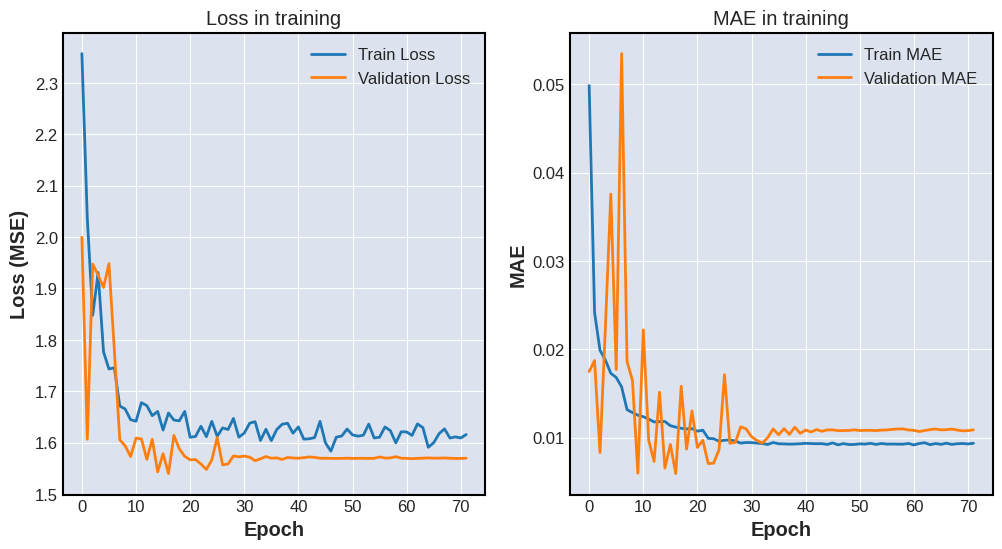

In [57]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss in training')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('MAE in training')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()

307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

معیارهای ارزیابی برای Open (داده‌های آموزشی):
MSE: 3.816176636470114e-05
RMSE: 0.006177521053359603
MAE: 0.00428640231748141
R² Score: 0.9982462137776045

معیارهای ارزیابی برای High (داده‌های آموزشی):
MSE: 8.74096439632403e-05
RMSE: 0.00934931248612647
MAE: 0.006107576804280149
R² Score: 0.9959760526841853

معیارهای ارزیابی برای Low (داده‌های آموزشی):
MSE: 8.429945491445599e-05
RMSE: 0.009181473460967798
MAE: 0.00612212042273061
R² Score: 0.9961266760308083

معیارهای ارزیابی برای Close (داده‌های آموزشی):
MSE: 0.00012719651424922702
RMSE: 0.011278143209288797
MAE: 0.007696414021162601
R² Score: 0.9941520255308884

دقت جهت برای Close (داده‌های آموزشی): 48.35489457064276%


/tmp/ipykernel_134/2896269705.py:77: UserWarning: Glyph 1608 (\N{ARABIC LETTER WAW}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_134/2896269705.py:77: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_134/2896269705.py:77: UserWarning: Glyph 1575 (\N{ARABIC LETTER ALEF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_134/2896269705.py:77: UserWarning: Glyph 1602 (\N{ARABIC LETTER QAF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_134/2896269705.py:77: UserWarning: Glyph 1593 (\N{ARABIC LETTER AIN}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_134/2896269705.py:77: UserWarning: Glyph 1740 (\N{ARABIC LETTER FARSI YEH}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_134/2896269705.py:77: UserWarning: Glyph 1583 (\N{ARABIC LETTER DAL}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_134/2896269705.py:77: UserWarning: Glyph 1585 (\N{ARAB

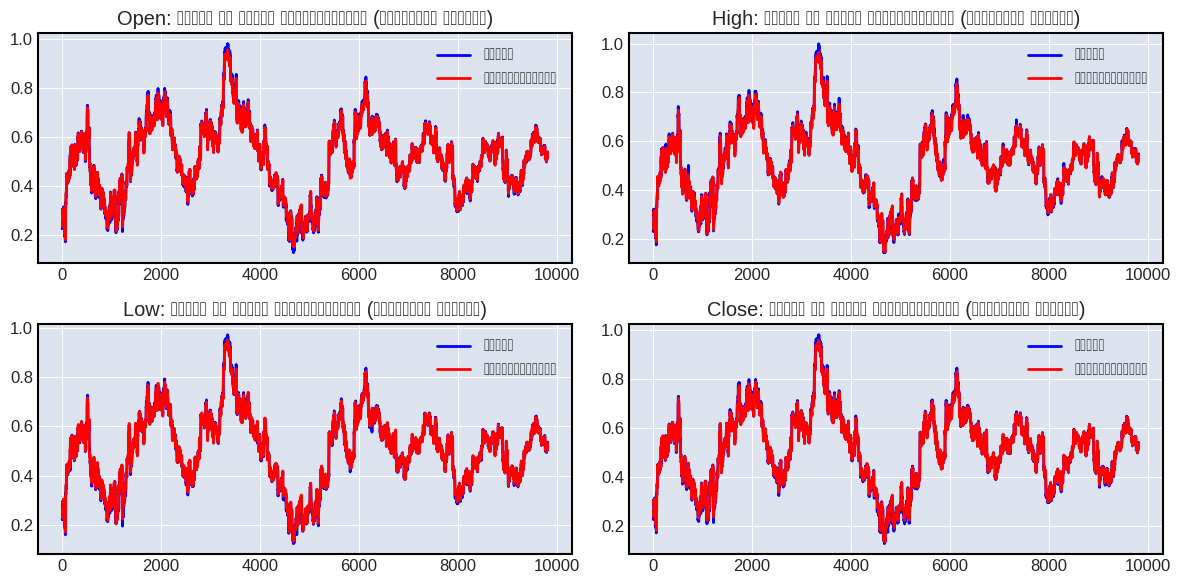

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 7. پیش‌بینی برای داده‌های آموزشی
predictions_train = model.predict(X_train)  # شکل: (n_samples, 4, 1) یا (n_samples, 4)

# 8. بررسی شکل پیش‌بینی‌ها و تنظیم آن
# اگر پیش‌بینی‌ها سه‌بعدی هستند (n_samples, 4, 1)، به دو‌بعدی (n_samples, 4) تبدیل می‌کنیم
if len(predictions_train.shape) == 3 and predictions_train.shape[2] == 1:
    predictions_train = predictions_train.reshape(predictions_train.shape[0], predictions_train.shape[1])  # (n_samples, 4)
if len(y_train.shape) == 3 and y_train.shape[2] == 1:
    y_train = y_train.reshape(y_train.shape[0], y_train.shape[1])  # (n_samples, 4)

# 9. چون نرمال‌سازی نداریم، نیازی به برگرداندن مقیاس نیست
# مستقیماً مقادیر پیش‌بینی‌شده و واقعی را استفاده می‌کنیم
predictions_open_train = predictions_train[:, 0]  # شکل: (n_samples,)
predictions_high_train = predictions_train[:, 1]
predictions_low_train = predictions_train[:, 2]
predictions_close_train = predictions_train[:, 3]

y_train_open = y_train[:, 0]
y_train_high = y_train[:, 1]
y_train_low = y_train[:, 2]
y_train_close = y_train[:, 3]

# 10. محاسبه معیارها برای هر مقدار (داده‌های آموزشی)
def calculate_metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\nمعیارهای ارزیابی برای {name} (داده‌های آموزشی):")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")
    print(f"R² Score: {r2}")

calculate_metrics(y_train_open, predictions_open_train, "Open")
calculate_metrics(y_train_high, predictions_high_train, "High")
calculate_metrics(y_train_low, predictions_low_train, "Low")
calculate_metrics(y_train_close, predictions_close_train, "Close")

# 11. دقت جهت برای Close (داده‌های آموزشی)
correct_directions_train = np.sum(np.sign(predictions_close_train[1:] - predictions_close_train[:-1]) == 
                                 np.sign(y_train_close[1:] - y_train_close[:-1]))
directional_accuracy_train = correct_directions_train / (len(predictions_close_train) - 1)
print(f"\nدقت جهت برای Close (داده‌های آموزشی): {directional_accuracy_train * 100}%")

# 12. رسم پیش‌بینی‌ها (داده‌های آموزشی)
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.plot(y_train_open, label='واقعی', color='blue')
plt.plot(predictions_open_train, label='پیش‌بینی‌شده', color='red')
plt.title('Open: واقعی در مقابل پیش‌بینی‌شده (داده‌های آموزشی)')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(y_train_high, label='واقعی', color='blue')
plt.plot(predictions_high_train, label='پیش‌بینی‌شده', color='red')
plt.title('High: واقعی در مقابل پیش‌بینی‌شده (داده‌های آموزشی)')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(y_train_low, label='واقعی', color='blue')
plt.plot(predictions_low_train, label='پیش‌بینی‌شده', color='red')
plt.title('Low: واقعی در مقابل پیش‌بینی‌شده (داده‌های آموزشی)')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(y_train_close, label='واقعی', color='blue')
plt.plot(predictions_close_train, label='پیش‌بینی‌شده', color='red')
plt.title('Close: واقعی در مقابل پیش‌بینی‌شده (داده‌های آموزشی)')
plt.legend()

plt.tight_layout()
plt.show()

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

معیارهای ارزیابی برای Open:
MSE: 2.129586240487725e-06
RMSE: 0.001459310193374844
MAE: 0.0007472659266655147
R² Score: 0.9923336234116661

معیارهای ارزیابی برای High:
MSE: 1.3462863512536805e-06
RMSE: 0.0011602958033422686
MAE: 0.0007583600283756293
R² Score: 0.9950794362219959

معیارهای ارزیابی برای Low:
MSE: 2.7824020860187177e-06
RMSE: 0.0016680533822449202
MAE: 0.0009654956901811242
R² Score: 0.9901350360882201

معیارهای ارزیابی برای Close:
MSE: 2.1565414319661746e-06
RMSE: 0.0014685167455518423
MAE: 0.0009687131403323489
R² Score: 0.9922358604200717

دقت جهت برای Close: 47.26976365118175%


/tmp/ipykernel_134/30884136.py:77: UserWarning: Glyph 1608 (\N{ARABIC LETTER WAW}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_134/30884136.py:77: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_134/30884136.py:77: UserWarning: Glyph 1575 (\N{ARABIC LETTER ALEF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_134/30884136.py:77: UserWarning: Glyph 1602 (\N{ARABIC LETTER QAF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_134/30884136.py:77: UserWarning: Glyph 1593 (\N{ARABIC LETTER AIN}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_134/30884136.py:77: UserWarning: Glyph 1740 (\N{ARABIC LETTER FARSI YEH}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_134/30884136.py:77: UserWarning: Glyph 1583 (\N{ARABIC LETTER DAL}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_134/30884136.py:77: UserWarning: Glyph 1585 (\N{ARABIC LETTER REH}) 

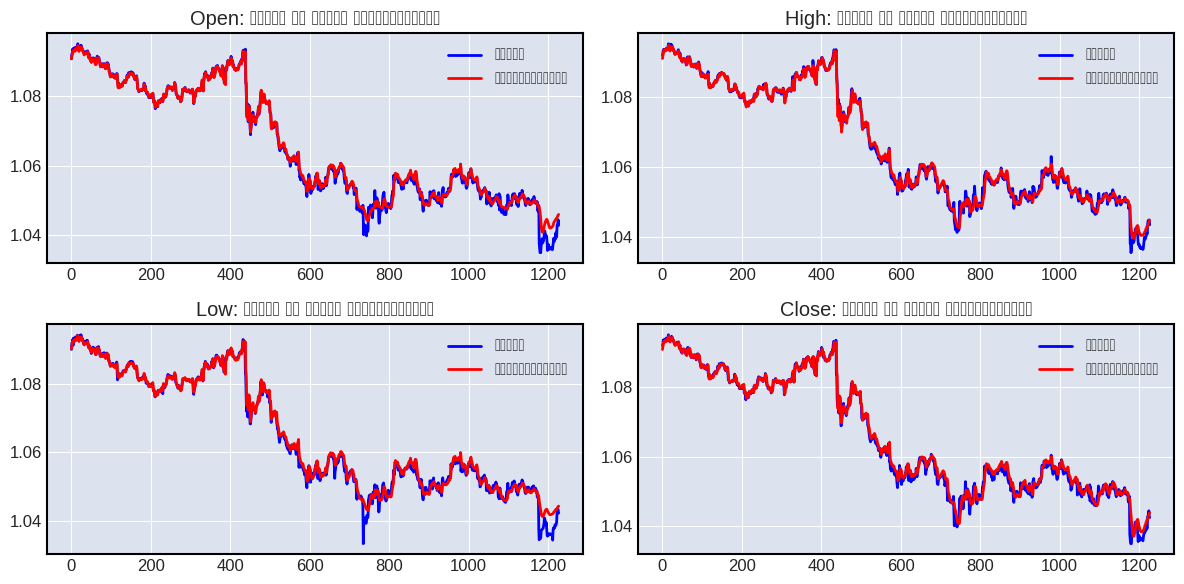

In [59]:
predictions = model.predict(X_test)  # شکل: (n_samples, 4, 1) یا (n_samples, 4)

# 7. بررسی شکل پیش‌بینی‌ها و تنظیم آن
# اگر پیش‌بینی‌ها سه‌بعدی هستند (n_samples, 4, 1)، به دو‌بعدی (n_samples, 4) تبدیل می‌کنیم
if len(predictions.shape) == 3 and predictions.shape[2] == 1:
    predictions = predictions.reshape(predictions.shape[0], predictions.shape[1])  # (n_samples, 4)
if len(y_test.shape) == 3 and y_test.shape[2] == 1:
    y_test = y_test.reshape(y_test.shape[0], y_test.shape[1])  # (n_samples, 4)

# 8. برگرداندن به مقیاس اصلی
flat_predictions = predictions.reshape(-1, 1)  # تبدیل به آرایه تخت
flat_y_test = y_test.reshape(-1, 1)
original_predictions = scaler.inverse_transform(flat_predictions).reshape(predictions.shape)
original_y_test = scaler.inverse_transform(flat_y_test).reshape(y_test.shape)

# 9. استخراج مقادیر Open, High, Low, Close
predictions_open = original_predictions[:, 0]  # شکل: (n_samples,)
predictions_high = original_predictions[:, 1]
predictions_low = original_predictions[:, 2]
predictions_close = original_predictions[:, 3]

y_test_open = original_y_test[:, 0]
y_test_high = original_y_test[:, 1]
y_test_low = original_y_test[:, 2]
y_test_close = original_y_test[:, 3]

# 10. محاسبه معیارها برای هر مقدار
def calculate_metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\nمعیارهای ارزیابی برای {name}:")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")
    print(f"R² Score: {r2}")

calculate_metrics(y_test_open, predictions_open, "Open")
calculate_metrics(y_test_high, predictions_high, "High")
calculate_metrics(y_test_low, predictions_low, "Low")
calculate_metrics(y_test_close, predictions_close, "Close")

# 11. دقت جهت برای Close
correct_directions = np.sum(np.sign(predictions_close[1:] - predictions_close[:-1]) == 
                           np.sign(y_test_close[1:] - y_test_close[:-1]))
directional_accuracy = correct_directions / (len(predictions_close) - 1)
print(f"\nدقت جهت برای Close: {directional_accuracy * 100}%")

# 12. رسم پیش‌بینی‌ها
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.plot(y_test_open, label='واقعی', color='blue')
plt.plot(predictions_open, label='پیش‌بینی‌شده', color='red')
plt.title('Open: واقعی در مقابل پیش‌بینی‌شده')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(y_test_high, label='واقعی', color='blue')
plt.plot(predictions_high, label='پیش‌بینی‌شده', color='red')
plt.title('High: واقعی در مقابل پیش‌بینی‌شده')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(y_test_low, label='واقعی', color='blue')
plt.plot(predictions_low, label='پیش‌بینی‌شده', color='red')
plt.title('Low: واقعی در مقابل پیش‌بینی‌شده')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(y_test_close, label='واقعی', color='blue')
plt.plot(predictions_close, label='پیش‌بینی‌شده', color='red')
plt.title('Close: واقعی در مقابل پیش‌بینی‌شده')
plt.legend()

plt.tight_layout()
plt.show()

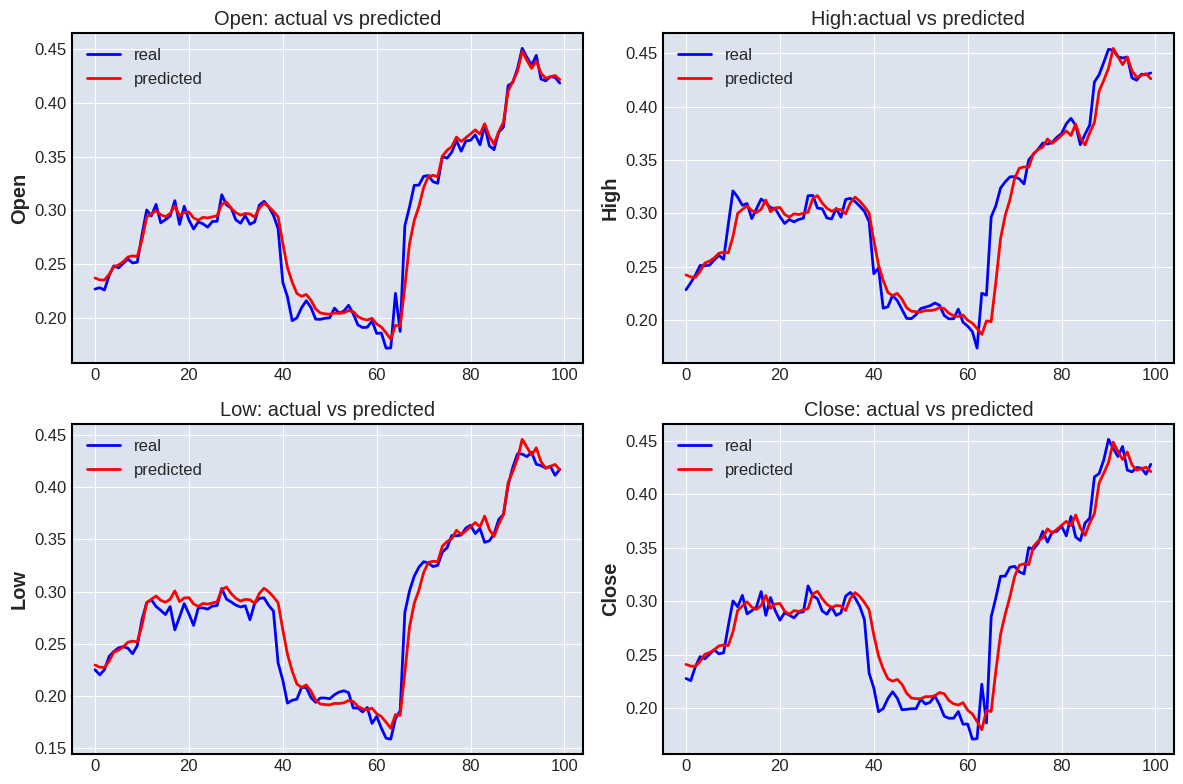

In [60]:
n_samples = 100  # تعداد نمونه‌هایی که می‌خوای نشون بدی

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(y_train_open[:n_samples], label='real', color='blue')
plt.plot(predictions_open_train[:n_samples], label='predicted', color='red')
plt.title('Open: actual vs predicted')
plt.ylabel('Open')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(y_train_high[:n_samples], label='real', color='blue')
plt.plot(predictions_high_train[:n_samples], label='predicted', color='red')
plt.title('High:actual vs predicted')
plt.ylabel('High')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(y_train_low[:n_samples], label='real', color='blue')
plt.plot(predictions_low_train[:n_samples], label='predicted', color='red')
plt.title('Low: actual vs predicted')
plt.ylabel('Low')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(y_train_close[:n_samples], label='real', color='blue')
plt.plot(predictions_close_train[:n_samples], label='predicted', color='red')
plt.title('Close: actual vs predicted')
plt.ylabel('Close')
plt.legend()

plt.tight_layout()
plt.show()

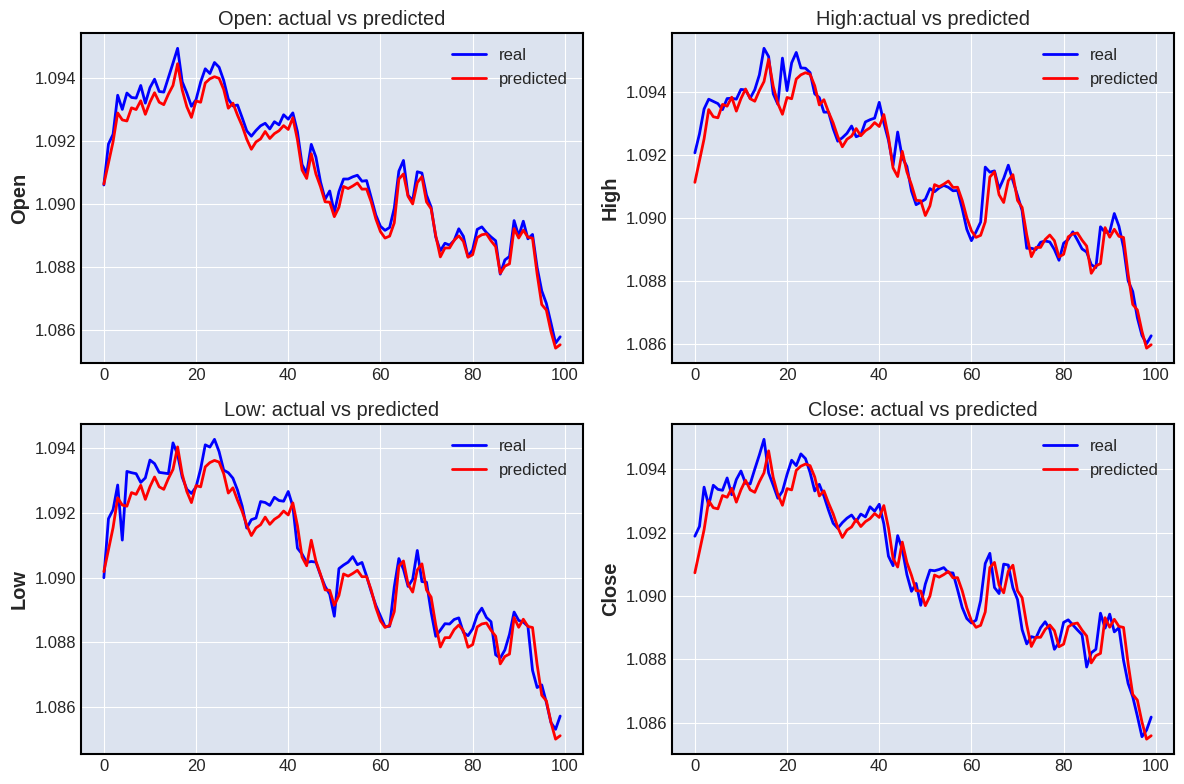

In [61]:
n_samples = 100  # تعداد نمونه‌هایی که می‌خوای نشون بدی

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(y_test_open[:n_samples], label='real', color='blue')
plt.plot(predictions_open[:n_samples], label='predicted', color='red')
plt.title('Open: actual vs predicted')
plt.ylabel('Open')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(y_test_high[:n_samples], label='real', color='blue')
plt.plot(predictions_high[:n_samples], label='predicted', color='red')
plt.title('High:actual vs predicted')
plt.ylabel('High')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(y_test_low[:n_samples], label='real', color='blue')
plt.plot(predictions_low[:n_samples], label='predicted', color='red')
plt.title('Low: actual vs predicted')
plt.ylabel('Low')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(y_test_close[:n_samples], label='real', color='blue')
plt.plot(predictions_close[:n_samples], label='predicted', color='red')
plt.title('Close: actual vs predicted')
plt.ylabel('Close')
plt.legend()

plt.tight_layout()
plt.show()

In [55]:
data.head()

,Date,Open,High,Low,Close,Volume
33544,2023-01-02 00:00:00,1.06970,1.07066,1.06788,1.06929,2477.42
33545,2023-01-02 01:00:00,1.06896,1.07047,1.06829,1.07005,4932.96
33546,2023-01-02 02:00:00,1.07007,1.07058,1.06912,1.07040,3522.13
33547,2023-01-02 03:00:00,1.07041,1.07087,1.06919,1.06977,432.28
33548,2023-01-02 04:00:00,1.06977,1.06977,1.06862,1.06904,1581.30


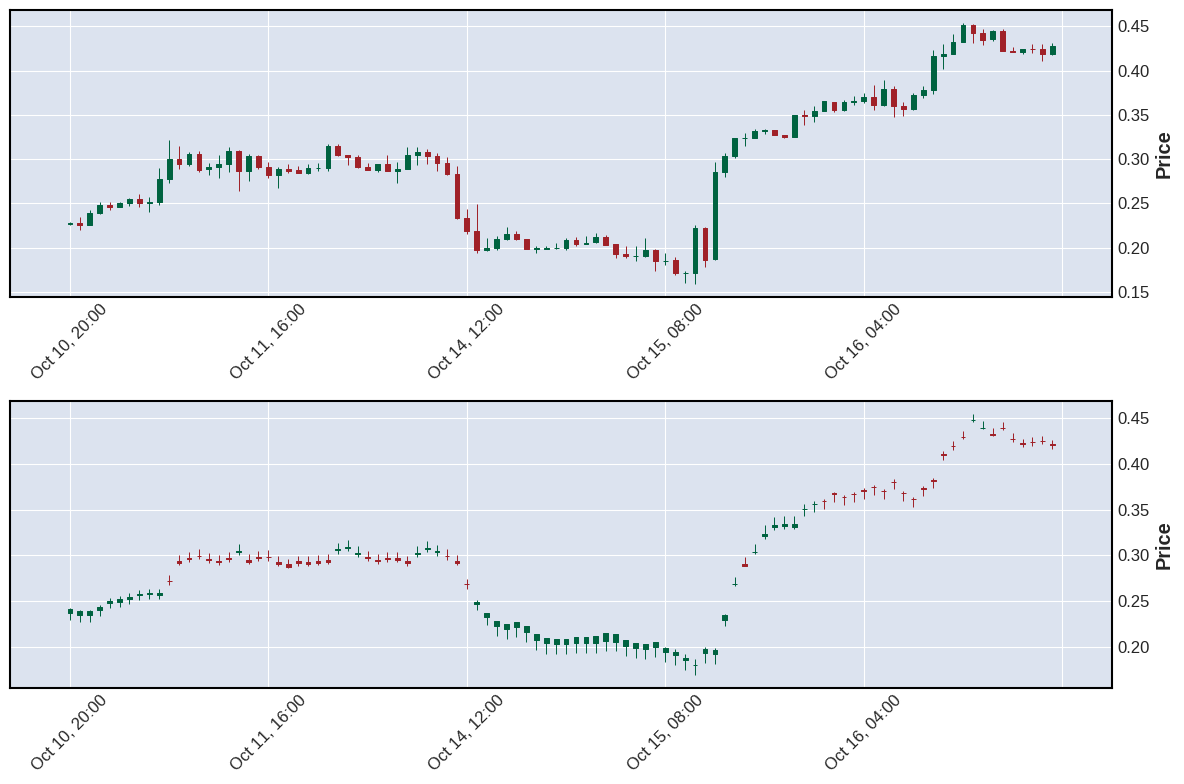

In [62]:
import mplfinance as mpf
data['Date'] = pd.to_datetime(data['Date'], format='mixed', dayfirst=True)
dates = data['Date'].iloc[-len(predictions):].values[:n_samples]
dates = pd.to_datetime(dates)  # تبدیل به datetime

predicted_candles = pd.DataFrame({
    'Date': dates,
    'Open': predictions_open_train[:n_samples].flatten(),
    'High': predictions_high_train[:n_samples].flatten(),
    'Low': predictions_low_train[:n_samples].flatten(),
    'Close': predictions_close_train[:n_samples].flatten()
})
predicted_candles.set_index('Date', inplace=True)
# مطمئن می‌شیم ایندکس DatetimeIndex باشه
predicted_candles.index = pd.DatetimeIndex(predicted_candles.index)

actual_candles = pd.DataFrame({
    'Date': dates,
    'Open': y_train_open[:n_samples].flatten(),
    'High': y_train_high[:n_samples].flatten(),
    'Low': y_train_low[:n_samples].flatten(),
    'Close': y_train_close[:n_samples].flatten()
})
actual_candles.set_index('Date', inplace=True)
# مطمئن می‌شیم ایندکس DatetimeIndex باشه
actual_candles.index = pd.DatetimeIndex(actual_candles.index)

# رسم کندل‌ها با استفاده از mpf.make_subplots
# به جای plt.subplots، از خود mplfinance برای مدیریت زیرنمودارها استفاده می‌کنیم
fig = mpf.figure(figsize=(12, 8))
ax1 = fig.add_subplot(2, 1, 1)
ax2 = fig.add_subplot(2, 1, 2, sharex=ax1)

# رسم کندل‌های واقعی و پیش‌بینی‌شده
mpf.plot(actual_candles, type='candle', style='charles', ax=ax1)
mpf.plot(predicted_candles, type='candle', style='charles', ax=ax2)

# تنظیم فاصله بین زیرنمودارها
fig.tight_layout()
mpf.show()

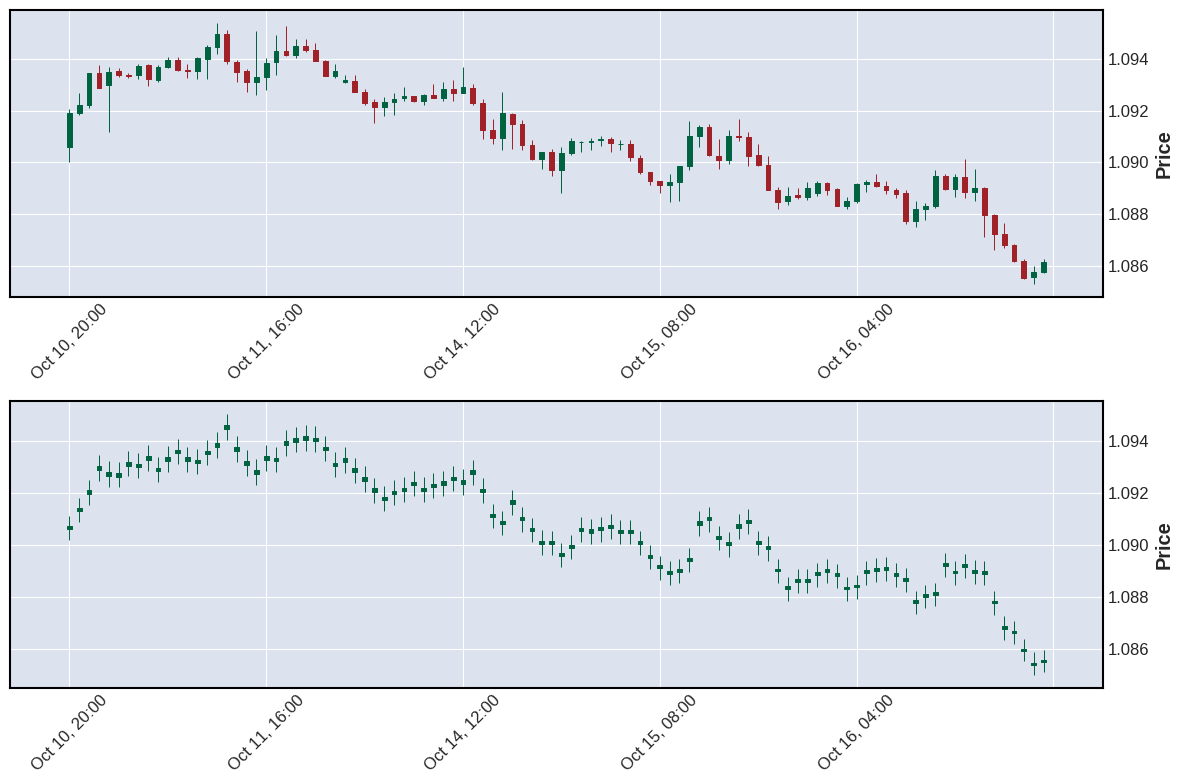

In [63]:
import mplfinance as mpf
data['Date'] = pd.to_datetime(data['Date'], format='mixed', dayfirst=True)
dates = data['Date'].iloc[-len(predictions):].values[:n_samples]
dates = pd.to_datetime(dates)  # تبدیل به datetime

predicted_candles = pd.DataFrame({
    'Date': dates,
    'Open': predictions_open[:n_samples].flatten(),
    'High': predictions_high[:n_samples].flatten(),
    'Low': predictions_low[:n_samples].flatten(),
    'Close': predictions_close[:n_samples].flatten()
})
predicted_candles.set_index('Date', inplace=True)
# مطمئن می‌شیم ایندکس DatetimeIndex باشه
predicted_candles.index = pd.DatetimeIndex(predicted_candles.index)

actual_candles = pd.DataFrame({
    'Date': dates,
    'Open': y_test_open[:n_samples].flatten(),
    'High': y_test_high[:n_samples].flatten(),
    'Low': y_test_low[:n_samples].flatten(),
    'Close': y_test_close[:n_samples].flatten()
})
actual_candles.set_index('Date', inplace=True)
# مطمئن می‌شیم ایندکس DatetimeIndex باشه
actual_candles.index = pd.DatetimeIndex(actual_candles.index)

# رسم کندل‌ها با استفاده از mpf.make_subplots
# به جای plt.subplots، از خود mplfinance برای مدیریت زیرنمودارها استفاده می‌کنیم
fig = mpf.figure(figsize=(12, 8))
ax1 = fig.add_subplot(2, 1, 1)
ax2 = fig.add_subplot(2, 1, 2, sharex=ax1)

# رسم کندل‌های واقعی و پیش‌بینی‌شده
mpf.plot(actual_candles, type='candle', style='charles', ax=ax1)
mpf.plot(predicted_candles, type='candle', style='charles', ax=ax2)

# تنظیم فاصله بین زیرنمودارها
fig.tight_layout()
mpf.show()

In [ ]:
data['Date'] = pd.to_datetime(data['Date'], format='mixed', dayfirst=True)
dates = data['Date'].iloc[-len(predictions):].values[:n_samples]
dates = pd.to_datetime(dates)  # تبدیل به datetime

predicted_candles = pd.DataFrame({
    'Date': dates,
    'Open': predictions_open[:n_samples].flatten(),
    'High': predictions_high[:n_samples].flatten(),
    'Low': predictions_low[:n_samples].flatten(),
    'Close': predictions_close[:n_samples].flatten()
})
predicted_candles.set_index('Date', inplace=True)
# مطمئن می‌شیم ایندکس DatetimeIndex باشه
predicted_candles.index = pd.DatetimeIndex(predicted_candles.index)

actual_candles = pd.DataFrame({
    'Date': dates,
    'Open': y_test_open[:n_samples].flatten(),
    'High': y_test_high[:n_samples].flatten(),
    'Low': y_test_low[:n_samples].flatten(),
    'Close': y_test_close[:n_samples].flatten()
})
actual_candles.set_index('Date', inplace=True)
# مطمئن می‌شیم ایندکس DatetimeIndex باشه
actual_candles.index = pd.DatetimeIndex(actual_candles.index)

fig = mpf.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1)

mpf.plot(actual_candles, type='candle', style='charles', ax=ax)


# کندل‌های پیش‌بینی‌شده (پررنگ) روی همون محور
mpf.plot(predicted_candles, type='candle', style='charles', ax=ax)


# نمایش نمودار
fig.tight_layout()
mpf.show()

In [ ]:
predictions[-1]

In [ ]:
y_test[-1]